In [ ]:
import numpy as np
import matplotlib.pyplot as plt

true_value = 2/3  #simplyfication for both functions returns 2/3

In [ ]:
x = np.logspace(-20, 20, 2000)  #choose wide range  - asked AI, I dont know which range makes sense

# define both functions (as given on the exercise sheet)
def f(x):
    return (x**3 + 1/3) - (x**3 - 1/3)

def g(x):
    return ((3 + x**3/3) - (3 - x**3/3)) / x**3

f_vals = f(x) # numerical evaluations of f(x) and g(x)
g_vals = g(x)

rel_err_f = np.abs(f_vals - true_value) / true_value # calculate relative error of f and g
rel_err_g = np.abs(g_vals - true_value) / true_value

In [ ]:
mask_f_1pct = rel_err_f > 0.01 # mask shows where error exceeds an error of 1percent
mask_g_1pct = rel_err_g > 0.01

print("f(x) deviates >1% for x in approx:")
print(x[mask_f_1pct][:10], "...")

print("\ng(x) deviates >1% for x in approx:")
print(x[mask_g_1pct][:10], "...")

f(x) deviates >1% for x in approx:
[42886.06091099 44908.25324946 47025.7973588  49243.18932975
 51565.1372557  53996.57122924 56542.65381002 59208.79098612
 62000.64365243 64924.13963017] ...

g(x) deviates >1% for x in approx:
[1.00000000e-20 1.04715267e-20 1.09652872e-20 1.14823298e-20
 1.20237523e-20 1.25907043e-20 1.31843897e-20 1.38060689e-20
 1.44570619e-20 1.51387510e-20] ...


In [ ]:
mask_f_zero = (f_vals == 0)  # mask shows where numerical evaluation is equal to zero
mask_g_zero = (g_vals == 0)

print("f(x) == 0 for x approx:")
print(x[mask_f_zero][:10], "...") 

print("\ng(x) == 0 for x approx:")
print(x[mask_g_zero][:10], "...")


f(x) == 0 for x approx:
[170850.52125896 178906.57974917 187342.50291827 196176.20240066
 205426.43441213 215112.83957416 225255.98461599 235877.40604312
 246999.65586476 258646.34947766] ...

g(x) == 0 for x approx:
[1.00000000e-20 1.04715267e-20 1.09652872e-20 1.14823298e-20
 1.20237523e-20 1.25907043e-20 1.31843897e-20 1.38060689e-20
 1.44570619e-20 1.51387510e-20] ...


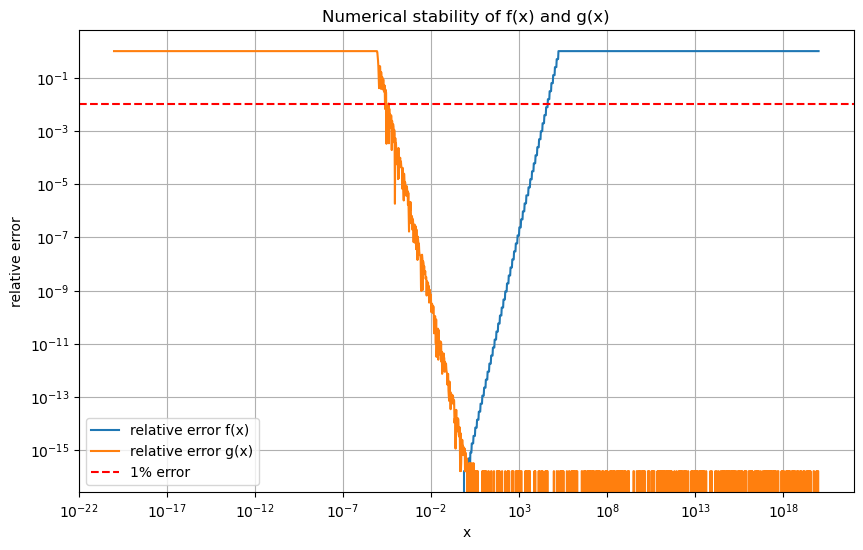

In [6]:
plt.figure(figsize=(10,6))
plt.loglog(x, rel_err_f, label="relative error f(x)")
plt.loglog(x, rel_err_g, label="relative error g(x)")
plt.axhline(0.01, color='red', linestyle='--', label="1% error")
plt.xlabel("x")
plt.ylabel("relative error")
plt.title("Numerical stability of f(x) and g(x)")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [ ]:
x32 = np.logspace(-20, 20, 2000, dtype=np.float32)
x64 = np.logspace(-20, 20, 2000, dtype=np.float64)

f32 = f(x32)
f64 = f(x64)

g32 = g(x32)
g64 = g(x64)

err_f32 = np.abs(f32 - true_value) / true_value
err_f64 = np.abs(f64 - true_value) / true_value
err_g32 = np.abs(g32 - true_value) / true_value
err_g64 = np.abs(g64 - true_value) / true_value  

#give runtimeWarning because (10⁻²⁰)³ = 10⁻⁶⁰ cannot be represented in a 64 bit float, but still works - too bad? fix it?


/tmp/ipykernel_6850/4225921703.py:4: RuntimeWarning: overflow encountered in power
  return (x**3 + 1/3) - (x**3 - 1/3)
/tmp/ipykernel_6850/4225921703.py:4: RuntimeWarning: invalid value encountered in subtract
  return (x**3 + 1/3) - (x**3 - 1/3)
/tmp/ipykernel_6850/4225921703.py:7: RuntimeWarning: overflow encountered in power
  return ((3 + x**3/3) - (3 - x**3/3)) / x**3
/tmp/ipykernel_6850/4225921703.py:7: RuntimeWarning: invalid value encountered in divide
  return ((3 + x**3/3) - (3 - x**3/3)) / x**3


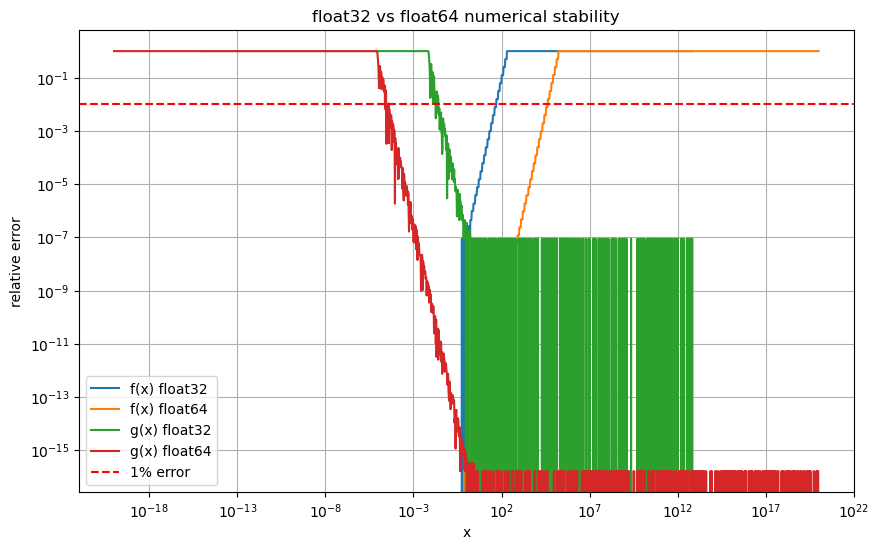

In [8]:
plt.figure(figsize=(10,6))
plt.loglog(x32, err_f32, label="f(x) float32")
plt.loglog(x64, err_f64, label="f(x) float64")
plt.loglog(x32, err_g32, label="g(x) float32")
plt.loglog(x64, err_g64, label="g(x) float64")
plt.axhline(0.01, color='red', linestyle='--', label="1% error")
plt.xlabel("x")
plt.ylabel("relative error")
plt.title("float32 vs float64 numerical stability")
plt.legend()
plt.grid(True, which="both")
plt.show()
